Citations: Andrew Lucas: Ising formulations of many NP Problems. arXiv:1302.5843. 
https://arxiv.org/abs/1302.5843

Ising machine: Largest Clique

A clique is a subgroup of nodes in an undirected graph where each node is
connected via an edge to every other node. The NP-hard version of the original
cliques problem is to find (one of) the largest clique(s) in the graph.

Instead of the decision Hamiltonian (Lucas Eq.13, which targets H=0 for a
specific K), we use an optimization formulation that directly maximises the
clique size. The idea:

- H_A = A * sum_{(u,v) not in E} x_u * x_v  (penalises selecting non-adjacent vertices)
- H_B = -C * sum_v x_v                       (rewards selecting more vertices)

Any ground state with H_A = 0 is a valid clique. The H_B term pushes toward
the largest one. Choose C < A so the penalty is never worth violating.

This is the complement-graph version of MIS (set-packing): a clique in G is an independent
set in the complement of G.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from helpers.helpers import generate_adjacency_matrix_undirected

In [ ]:
# ---- Hamiltonian Penalty Terms ----

def get_ha(adjacency_matrix, xalpha, A):
    """Penalty for selecting two vertices that are NOT connected by an edge.
    If two selected vertices lack an edge, they can't both be in a clique."""
    N = len(xalpha)
    ha = 0
    for u in range(N):
        for v in range(u + 1, N):
            if adjacency_matrix[u, v] == 0:  # no edge between u and v
                ha += xalpha[u] * xalpha[v]
    return A * ha

def get_hb(xalpha, C):
    """Reward for selecting more vertices (larger clique)."""
    return -C * np.sum(xalpha)

def calc_energy(adjacency_matrix, xalpha, A, C):
    return get_ha(adjacency_matrix, xalpha, A) + get_hb(xalpha, C)

In [ ]:
# ---- Annealing via Metropolis-Hastings ----

def annealing(adjacency_matrix, xalpha, A, C, T_start, steps):
    N = len(xalpha)
    xalpha = xalpha.copy()
    energy = calc_energy(adjacency_matrix, xalpha, A, C)
    best_xalpha = xalpha.copy()
    best_energy = energy

    for step in range(steps):
        j = np.random.randint(0, N)
        xalpha[j] = 1 - xalpha[j]
        new_energy = calc_energy(adjacency_matrix, xalpha, A, C)
        delta_energy = new_energy - energy

        T = T_start / (1 + step * 0.001)
        if delta_energy < 0 or np.random.rand() < np.exp(-delta_energy / T):
            energy = new_energy
            if energy < best_energy:
                best_energy = energy
                best_xalpha = xalpha.copy()
        else:
            xalpha[j] = 1 - xalpha[j]

    return best_xalpha, best_energy

In [4]:
# ---- Plotting ----

def plot_clique(adjacency_matrix, xalpha):
    N = adjacency_matrix.shape[0]
    G = nx.from_numpy_array(adjacency_matrix)
    pos = nx.spring_layout(G, seed=42)

    clique_nodes = [i for i in range(N) if xalpha[i] == 1]
    colours = ['red' if xalpha[i] == 1 else 'lightblue' for i in range(N)]

    # highlight clique edges
    clique_edges = [(u, v) for u in clique_nodes for v in clique_nodes
                    if u < v and adjacency_matrix[u, v] == 1]
    other_edges = [(u, v) for u, v in G.edges() if (u, v) not in clique_edges]

    plt.figure(figsize=(6, 6))
    nx.draw_networkx_edges(G, pos, edgelist=other_edges, edge_color='lightgray', width=1)
    nx.draw_networkx_edges(G, pos, edgelist=clique_edges, edge_color='red', width=2)
    nx.draw_networkx_nodes(G, pos, node_color=colours, node_size=500)
    nx.draw_networkx_labels(G, pos, font_size=12)

    plt.title(f"Largest Clique (size {len(clique_nodes)}): {clique_nodes}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [5]:
# ---- Verify clique ----

def verify_clique(adjacency_matrix, xalpha):
    """Check that all selected vertices are pairwise connected."""
    selected = [i for i in range(len(xalpha)) if xalpha[i] == 1]
    for i in range(len(selected)):
        for j in range(i + 1, len(selected)):
            if adjacency_matrix[selected[i], selected[j]] == 0:
                print(f"INVALID: vertices {selected[i]} and {selected[j]} are not connected")
                return False
    print(f"VALID clique of size {len(selected)}: {selected}")
    return True

Energy: -3.0
H_A (should be 0): 0.0
VALID clique of size 3: [0, 1, 2]


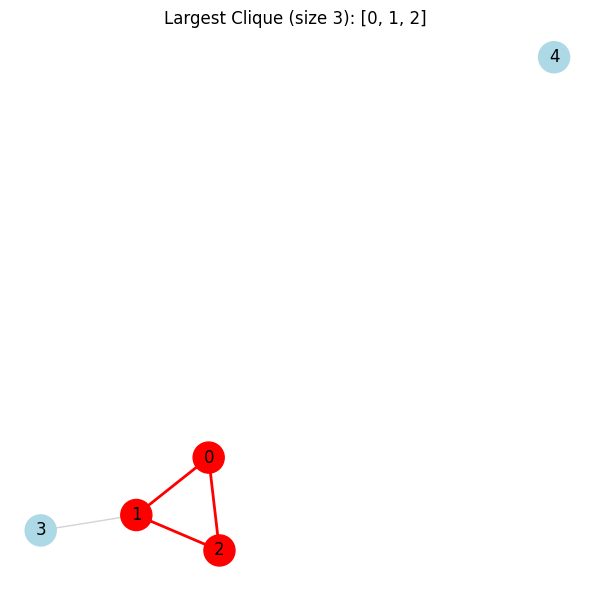

In [ ]:
# ---- Run on a small hand-crafted graph ----
# vertices: 0-1, 0-2, 1-2, 1-3 connected. Largest clique is {0,1,2} (triangle)

adjacency_matrix = np.array([
    [0, 1, 1, 0, 0],
    [1, 0, 1, 1, 0],
    [1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0]
], dtype=np.int64)

N = len(adjacency_matrix)
A = 2.0
C = 1.0  # C < A
T_start = 5.0
steps = 100000

xalpha = np.random.randint(2, size=N)
best_xalpha, best_energy = annealing(adjacency_matrix, xalpha, A, C, T_start, steps)

print(f"Energy: {best_energy}")
print(f"H_A (should be 0): {get_ha(adjacency_matrix, best_xalpha, A)}")
verify_clique(adjacency_matrix, best_xalpha)
plot_clique(adjacency_matrix, best_xalpha)

Largest clique found: [0, 1, 6, 13, 14, 19]
Size: 6
Energy: -6.0
H_A (should be 0): 0.0
VALID clique of size 6: [0, 1, 6, 13, 14, 19]


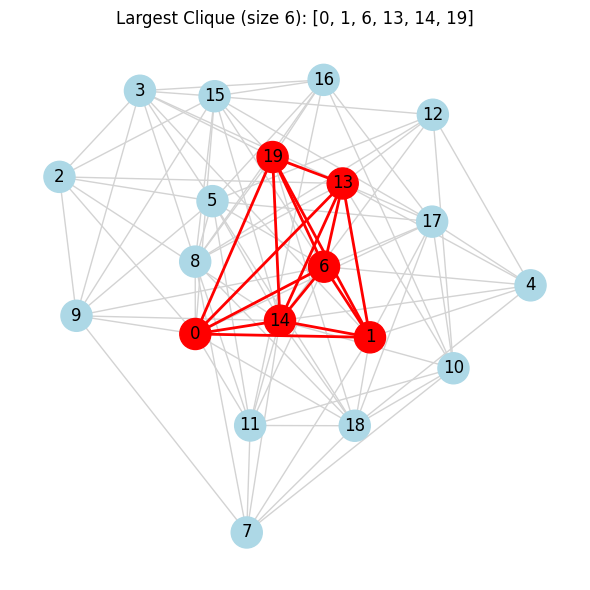

In [ ]:
# ---- Run on a larger random graph ----

N = 20
adj_p = 0.5
A = 2.0
C = 1.0
T_start = 5.0
steps = 500000

adjacency_matrix = generate_adjacency_matrix_undirected(N, adj_p)
xalpha = np.random.randint(2, size=N)

best_xalpha, best_energy = annealing(adjacency_matrix, xalpha, A, C, T_start, steps)

clique_nodes = [i for i in range(N) if best_xalpha[i] == 1]
print(f"Largest clique found: {clique_nodes}")
print(f"Size: {len(clique_nodes)}")
print(f"Energy: {best_energy}")
print(f"H_A (should be 0): {get_ha(adjacency_matrix, best_xalpha, A)}")
verify_clique(adjacency_matrix, best_xalpha)
plot_clique(adjacency_matrix, best_xalpha)

In [8]:
# ---- Compare with networkx brute-force (for small graphs) ----

G = nx.from_numpy_array(adjacency_matrix)
nx_clique = max(nx.find_cliques(G), key=len)
print(f"NetworkX largest clique: {sorted(nx_clique)} (size {len(nx_clique)})")
print(f"Our result:             {sorted(clique_nodes)} (size {len(clique_nodes)})")

NetworkX largest clique: [0, 1, 6, 13, 14, 19] (size 6)
Our result:             [0, 1, 6, 13, 14, 19] (size 6)
